# LightGBM LambdaMART — Learning to Rank (MAP@7)

**Datasets:** `featured_full_train.csv` / `featured_full_test.csv`  
**Model:** `lgb.train` with `lambdarank` objective  
**CV:** StratifiedGroupKFold (3 folds) — stratifies on target `y` while keeping customers in one fold  
**Metric:** MAP@7 (OOF + test)  
**Explainability:** SHAP TreeExplainer + LightGBM gain-based importance

---

### Why LightGBM LambdaMART?

LightGBM's `lambdarank` objective implements the same LambdaMART gradient as CatBoost but with:
- **Histogram-based splits** — much faster than CatBoost's oblivious trees on wide feature sets
- **`lambdarank_truncation_level=7`** — restricts pairwise gradient computation to top-7 positions, directly aligning the loss with MAP@7
- **`label_gain=[0,1]`** — binary relevance (clicked vs not clicked)

### Pipeline

```
featured_full_train.csv
  → Drop leaky _grp_pct / _grp_zscore columns
  → Sort by [id2, id4] (customer + timestamp)
  → StratifiedGroupKFold (3 folds, stratified on y, grouped by id2)
  → lgb.train (lambdarank, eval map@7, early stopping 50 rounds)
  → group_sizes_from_ids() converts customer IDs to group size arrays for lgb.Dataset
  → OOF MAP@7 + test MAP@7
  → Feature importance (gain, avg across 3 models)
  → SHAP on best fold model
```

### Results Summary

| Split | MAP@7 |
|---|---|
| Fold 1 | 0.6834 |
| Fold 2 | 0.6596 |
| Fold 3 | 0.6547 |
| OOF | 0.6660 |
| **Test** | **0.6607** |

Note: LightGBM scores lower than CatBoost (0.7009) — likely due to CatBoost's oblivious tree structure being better suited to the interaction-heavy feature set here.

## 1. Imports

Core libraries: `numpy`, `pandas`, `matplotlib`. Model: `lightgbm` (v4.6.0). Explainability: `shap` (v0.51.0). CV: `sklearn.model_selection.StratifiedGroupKFold`. (Note: `LabelEncoder` is imported but not used — categoricals are already integer-encoded.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder

print(f'LightGBM version : {lgb.__version__}')
print(f'SHAP version     : {shap.__version__}')

LightGBM version : 4.6.0
SHAP version     : 0.51.0


## 2. Load Data

Reads `featured_full_train.csv` and `featured_full_test.csv` from the absolute path. Drops residual leaky columns (`_grp_pct`, `_grp_zscore`, `_is_train`) defensively.

Dataset stats after loading:
- Train: 616,602 rows × 350 features (fewer than CatBoost notebook due to different column set version)
- Test: 153,544 rows × 350 features
- Target: 4.88% positive (clicked)

In [2]:
TRAIN_PATH = '/Users/akashjaiswal/Desktop/amex-hackathon-4/final_notebooks/featured_full_train.csv'
TEST_PATH  = '/Users/akashjaiswal/Desktop/amex-hackathon-4/final_notebooks/featured_full_test.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Drop any leaky columns (within-group rank/zscore or _is_train flag)
leaky_cols = [c for c in train.columns
              if c.endswith('_grp_pct') or c.endswith('_grp_zscore') or c == '_is_train']
if leaky_cols:
    train.drop(columns=leaky_cols, inplace=True)
    test.drop(columns=[c for c in leaky_cols if c in test.columns], inplace=True)
    print(f'Dropped {len(leaky_cols)} leaky columns: {leaky_cols}')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')

Train shape : (616602, 350)
Test  shape : (153544, 350)


In [3]:
print(f'Target distribution (train):')
print(train['y'].value_counts(normalize=True).round(4))

Target distribution (train):
y
0    0.9512
1    0.0488
Name: proportion, dtype: float64


## 3. Feature & Column Definitions

- **`ID_COLS`** (`id1`–`id5`) — identifiers, excluded from training
- **`TARGET_COL`** (`y`) — binary click label
- **`GROUP_COL`** (`id2`) — customer ID used to define LTR query groups
- **`CAT_FEATURES = []`** — all categorical columns were already integer-encoded in `feature_engineering.ipynb`. Passing them as `categorical_feature` would trigger LightGBM's own histogram binning on top of clean integer codes — redundant and unnecessary.
- **`FEATURE_COLS`** — 344 total (238 raw `f`-columns + 106 engineered features)

In [4]:
ID_COLS    = ['id1', 'id2', 'id3', 'id4', 'id5']
TARGET_COL = 'y'
GROUP_COL  = 'id2'

In [5]:
# All categorical columns are already integer-encoded by feature_engineering.ipynb
# (pd.CategoricalDtype fitted on train rows only — no leakage).
# Passing them as categorical_feature would trigger LightGBM's own histogram
# binning on top of already-clean integer codes — redundant and unnecessary.
CAT_FEATURES = []

print('CAT_FEATURES = [] — all columns are already integer-encoded by feature_engineering.ipynb')

CAT_FEATURES = [] — all columns are already integer-encoded by feature_engineering.ipynb


In [6]:
FEATURE_COLS = [c for c in train.columns if c not in ID_COLS + [TARGET_COL]]

eng_features = [c for c in FEATURE_COLS if not c.startswith('f')]
raw_features = [c for c in FEATURE_COLS if c.startswith('f')]

print(f'Total feature columns  : {len(FEATURE_COLS)}')
print(f'  Raw f-columns        : {len(raw_features)}')
print(f'  Engineered features  : {len(eng_features)}')

Total feature columns  : 344
  Raw f-columns        : 238
  Engineered features  : 106


## 4. Preprocessing

Two steps before building LightGBM Datasets:

### 4A. Label-Encode Categoricals

No encoding needed — `feature_engineering.ipynb` already produced clean integer codes using `pd.CategoricalDtype` fitted on train rows only. This cell is retained as documentation of the intentional decision.

In [7]:
# LabelEncoder removed — all categorical columns are already integer-encoded by
# feature_engineering.ipynb (pd.CategoricalDtype fitted on train rows only).
# No re-encoding needed.
print('No LabelEncoder needed — categoricals already integer-encoded by feature_engineering.ipynb.')

No LabelEncoder needed — categoricals already integer-encoded by feature_engineering.ipynb.


### 4B. Sort

Sort by `[id2, id4]` (customer ID + timestamp). Unlike CatBoost which only requires contiguous groups, LightGBM's `lambdarank` benefits from **within-group temporal ordering** — it affects the group size arrays passed to `lgb.Dataset(group=...)` and ensures correct query-document alignment.

In [8]:
train = train.sort_values(['id2', 'id4']).reset_index(drop=True)
test  = test.sort_values(['id2', 'id4']).reset_index(drop=True)
print('Sorted by id2, id4 ✓')

Sorted by id2, id4 ✓


In [9]:
X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
g_train = train[GROUP_COL].values

X_test = test[FEATURE_COLS]
y_test = test[TARGET_COL]
g_test = test[GROUP_COL].values

print(f'Train : {X_train.shape}  |  positive rate : {y_train.mean():.4f}')
print(f'Test  : {X_test.shape}   |  positive rate : {y_test.mean():.4f}')

Train : (616602, 344)  |  positive rate : 0.0488
Test  : (153544, 344)   |  positive rate : 0.0455


## 5. MAP@K Evaluation Helpers

Same MAP@7 implementation as `catboost_lambdamart_ltr_base_model.ipynb` with one addition:

- `apk(actual, predicted, k)` — AP@K for a single query using a `seen` set to handle duplicate predictions correctly
- `map_at_k(y_true, y_score, k, groups)` — per-customer MAP@K
- **`group_sizes_from_ids(group_ids)`** — converts an array of customer IDs into a sorted array of group sizes (e.g. `[id2_a, id2_a, id2_b]` → `[2, 1]`). LightGBM's `lgb.Dataset` requires group sizes, not group IDs directly.

In [10]:
def apk(actual: list, predicted: list, k: int = 7) -> float:
    """Average Precision at K for a single query (binary relevance)."""
    if not actual:
        return 0.0
    predicted = predicted[:k]
    actual_set = set(actual)
    seen = set()
    score, hits = 0.0, 0.0
    for i, p in enumerate(predicted):
        if p in actual_set and p not in seen:
            seen.add(p)
            hits += 1
            score += hits / (i + 1.0)
    return score / min(len(actual), k)

In [11]:
def map_at_k(y_true, y_score, k: int = 7, groups=None) -> float:
    """MAP@K computed per customer (query group)."""
    y_true  = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if groups is None:
        order     = np.argsort(y_score)[::-1]
        actual    = list(np.where(y_true == 1)[0])
        predicted = list(order)
        return apk(actual, predicted, k)
    groups    = np.asarray(groups)
    ap_scores = []
    for grp in np.unique(groups):
        mask = groups == grp
        yt   = y_true[mask]
        ys   = y_score[mask]
        if yt.sum() == 0:
            continue
        order     = np.argsort(ys)[::-1]
        actual    = list(np.where(yt == 1)[0])
        predicted = list(order)
        ap_scores.append(apk(actual, predicted, k))
    return float(np.mean(ap_scores)) if ap_scores else 0.0

In [12]:
def group_sizes_from_ids(group_ids: np.ndarray) -> np.ndarray:
    """Convert group ids to group sizes for LightGBM Dataset."""
    _, counts = np.unique(group_ids, return_counts=True)
    return counts

print('MAP@K helpers defined.')

MAP@K helpers defined.


## 6. LightGBM LambdaMART Hyperparameters

| Parameter | Value | Reason |
|---|---|---|
| `objective` | `lambdarank` | LambdaMART pairwise ranking loss |
| `metric` | `map` | Monitor MAP during training |
| `eval_at` | `[7]` | Evaluate MAP at position 7 (MAP@7) |
| `lambdarank_truncation_level` | `7` | Only compute pairwise gradients for top-7 positions — focuses training signal on positions that affect MAP@7 |
| `label_gain` | `[0, 1]` | Binary relevance: 0=not clicked, 1=clicked |
| `n_estimators` | 1000 | Upper bound; early stopping terminates earlier |
| `learning_rate` | 0.05 | Conservative step size |
| `num_leaves` | 127 | Controls tree complexity (≈depth 7 equivalent) |
| `min_child_samples` | 20 | Minimum samples per leaf — prevents overfitting on small groups |
| `reg_lambda` | 3.0 | L2 regularisation on leaf weights |
| `colsample_bytree` | 0.8 | 80% feature subsampling per tree — reduces correlation between trees |
| `subsample` | 0.8 | 80% row subsampling per tree (with `subsample_freq=1`) |

In [13]:
LGB_PARAMS = dict(
    objective                   = 'lambdarank',
    metric                      = 'map',
    eval_at                     = [7],
    lambdarank_truncation_level = 7,
    label_gain                  = [0, 1],
    n_estimators                = 1000,
    learning_rate               = 0.05,
    num_leaves                  = 127,
    min_child_samples           = 20,
    reg_lambda                  = 3.0,
    colsample_bytree            = 0.8,
    subsample                   = 0.8,
    subsample_freq              = 1,
    random_state                = 42,
    n_jobs                      = -1,
    verbose                     = -1,
)

print('LGB_PARAMS configured.')

LGB_PARAMS configured.


## 7. 3-Fold StratifiedGroupKFold Cross-Validation

**Why StratifiedGroupKFold instead of random customer split?**
- `StratifiedGroupKFold` ensures each fold has roughly the same positive rate (≈4.88%) in the validation set — important because MAP@7 is sensitive to the fraction of positives per query
- It still respects group boundaries (no customer appears in both train and val)

For each fold:
1. Slice train/val by row indices from `gkf.split`
2. Convert customer IDs to group sizes using `group_sizes_from_ids`
3. Build `lgb.Dataset` with `group=` parameter (group sizes, not IDs)
4. Train with early stopping (50 rounds, monitoring val MAP@7)
5. Collect OOF predictions and 1/3-weighted test predictions

In [14]:
N_FOLDS = 3
gkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
fold_maps  = []
models     = []

splits = list(gkf.split(X_train, y_train, groups=g_train))

In [15]:
for fold, (tr_idx, val_idx) in enumerate(splits, 1):
    print(f'\n{"="*60}')
    print(f'FOLD {fold}/{N_FOLDS}')
    print(f'{"="*60}')

    X_tr,  X_val  = X_train.iloc[tr_idx],  X_train.iloc[val_idx]
    y_tr,  y_val  = y_train.iloc[tr_idx],  y_train.iloc[val_idx]
    g_tr,  g_val  = g_train[tr_idx],       g_train[val_idx]

    print(f'  Train: {len(X_tr):,} rows, {len(np.unique(g_tr)):,} customers')
    print(f'  Val  : {len(X_val):,} rows, {len(np.unique(g_val)):,} customers')

    # No categorical_feature — all columns are already integer-encoded
    train_ds = lgb.Dataset(
        X_tr, label=y_tr,
        group=group_sizes_from_ids(g_tr),
        free_raw_data=False
    )
    val_ds = lgb.Dataset(
        X_val, label=y_val,
        group=group_sizes_from_ids(g_val),
        free_raw_data=False,
        reference=train_ds
    )

    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]

    model = lgb.train(
        LGB_PARAMS, train_ds,
        valid_sets=[val_ds],
        callbacks=callbacks
    )

    val_scores = model.predict(X_val)
    oof_preds[val_idx] = val_scores
    test_preds += model.predict(X_test) / N_FOLDS

    fold_map = map_at_k(y_val.values, val_scores, k=7, groups=g_val)
    fold_maps.append(fold_map)
    models.append(model)

    print(f'  Best iteration : {model.best_iteration}')
    print(f'  Fold {fold} MAP@7  : {fold_map:.4f}')


FOLD 1/3
  Train: 409,885 rows, 24,817 customers
  Val  : 206,717 rows, 12,423 customers
[100]	valid_0's map@7: 0.964544
[200]	valid_0's map@7: 0.965619
[300]	valid_0's map@7: 0.965623
  Best iteration : 276
  Fold 1 MAP@7  : 0.6834

FOLD 2/3
  Train: 405,217 rows, 24,847 customers
  Val  : 211,385 rows, 12,393 customers
[100]	valid_0's map@7: 0.961754
  Best iteration : 148
  Fold 2 MAP@7  : 0.6596

FOLD 3/3
  Train: 418,102 rows, 24,816 customers
  Val  : 198,500 rows, 12,424 customers
[100]	valid_0's map@7: 0.963137
  Best iteration : 126
  Fold 3 MAP@7  : 0.6547


In [16]:
print(f'{"="*60}')
print(f'CV MAP@7 : {np.mean(fold_maps):.4f} ± {np.std(fold_maps):.4f}')
print(f'{"="*60}')

CV MAP@7 : 0.6659 ± 0.0126


## 8. OOF Evaluation

Computes MAP@7 on:
- **OOF predictions**: all training rows predicted once each by the fold model that never trained on them → **0.6660**
- **Test predictions**: average of 3 fold model predictions → **0.6607**

OOF ≈ Test confirms the CV procedure generalises well and the model is not overfitting the training data.

In [17]:
oof_map  = map_at_k(y_train.values, oof_preds, k=7, groups=g_train)
test_map = map_at_k(y_test.values,  test_preds, k=7, groups=g_test)

print(f'OOF  MAP@7 : {oof_map:.4f}')
print(f'Test MAP@7 : {test_map:.4f}')

OOF  MAP@7 : 0.6660
Test MAP@7 : 0.6607


In [18]:
summary = pd.DataFrame({
    'Split' : [f'Fold {i}' for i in range(1, N_FOLDS + 1)] + ['OOF', 'Test'],
    'MAP@7' : fold_maps + [oof_map, test_map],
}).set_index('Split')
summary.loc['CV Mean'] = [np.mean(fold_maps)]
print(summary.round(4).to_string())

          MAP@7
Split          
Fold 1   0.6834
Fold 2   0.6596
Fold 3   0.6547
OOF      0.6660
Test     0.6607
CV Mean  0.6659


## 9. Feature Importance (Gain)

Computes gain-based feature importance averaged across the 3 fold models. Gain measures the total reduction in the ranking loss contributed by all splits on a given feature — features with high gain are the most discriminative.

**Top features by gain:**
1. `time_since_last_seen` (61,246) — recency of last offer impression dominates
2. `time_since_last_click` (19,975) — time since last customer engagement
3. `pace_x_offer_popularity` (14,118) — interaction: recency pace × offer CTR
4. `f312` (8,689) — 7-day offer impression count
5. `session_event_count` (8,095) — position within the customer's session

Engineered features (non-`f*` columns) take 5 of the top 10 slots, validating the feature engineering effort.

In [19]:
feat_imp = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': np.mean(
        [m.feature_importance(importance_type='gain') for m in models], axis=0
    )
}).sort_values('importance', ascending=False)

print('Top 30 features (gain):')
print(feat_imp.head(30).to_string(index=False))

Top 30 features (gain):
                    feature   importance
       time_since_last_seen 61246.253602
      time_since_last_click 19975.371383
    pace_x_offer_popularity 14117.951404
                       f312  8689.003736
        session_event_count  8094.840534
                       f311  6286.904999
                       f210  4765.080013
    cx_merchant_click_share  4758.890697
                 pace_x_ctr  3522.231862
                       f337  3476.369834
                       f336  3103.972805
    no_of_clicks_previously  2923.438127
                       f314  2443.244846
                       f207  1715.491972
                       f340  1697.785844
                       f358  1695.784994
                       f313  1467.057421
    previous_offer_category  1361.218629
                       f216  1333.473324
cx_industry_vs_merchant_ctr  1231.068940
                       f219  1156.514413
                       f206  1096.632090
                       f361  1094

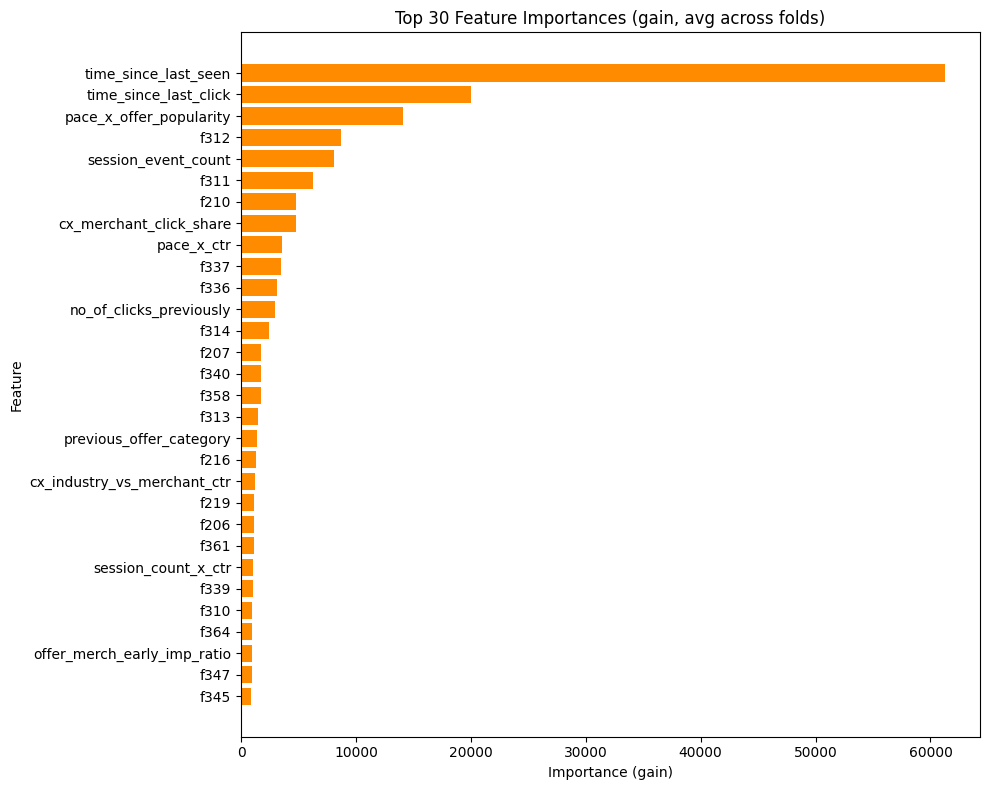

In [20]:
top_n = feat_imp.head(30).sort_values('importance').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_n['feature'], top_n['importance'], color='darkorange')
ax.set_title('Top 30 Feature Importances (gain, avg across folds)')
ax.set_xlabel('Importance (gain)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_featured.png', dpi=120)
plt.show()

## 10. SHAP Analysis

Uses `shap.TreeExplainer` on the best fold model (Fold 1, MAP@7 = 0.6834) to explain feature contributions.

SHAP values are computed on a random sample of 5,000 training rows (shape `(5000, 344)`). Five plots are produced — training summary, bar, dependence (top 4), waterfall, and a test-set summary to check if attribution patterns are stable out-of-sample.

In [21]:
best_fold_idx = int(np.argmax(fold_maps))
best_model = models[best_fold_idx]
print(f'Using best fold model (Fold {best_fold_idx + 1}, MAP@7 = {fold_maps[best_fold_idx]:.4f})')

Using best fold model (Fold 1, MAP@7 = 0.6834)


In [22]:
explainer = shap.TreeExplainer(best_model)

SHAP_SAMPLE = min(5000, len(X_train))
X_shap = X_train.sample(n=SHAP_SAMPLE, random_state=42)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP values computed for {SHAP_SAMPLE} samples')
print(f'Shape: {shap_values.shape}')

SHAP values computed for 5000 samples
Shape: (5000, 344)


### 10A. SHAP Summary Plot (Beeswarm)

Each row = one feature (top 30 by mean |SHAP|). Each dot = one sample. Color = feature value (red=high, blue=low). X-axis = SHAP value (positive pushes ranking score up).

Saved to `output/shap_summary_featured.png`.

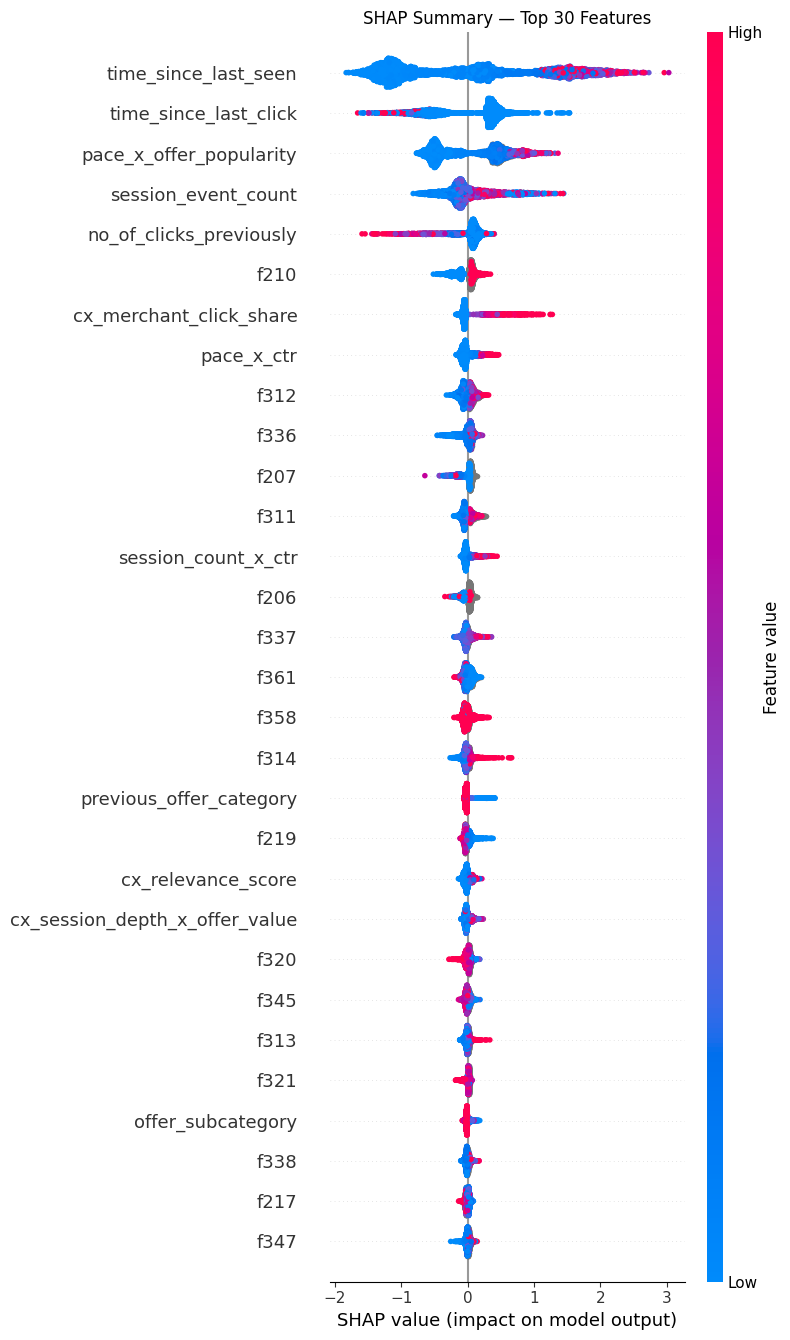

In [24]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, max_display=30, show=False)
plt.title('SHAP Summary — Top 30 Features')
plt.tight_layout()
plt.savefig('/Users/akashjaiswal/Desktop/amex-hackathon-4/output/shap_summary_featured.png', dpi=120, bbox_inches='tight')
plt.show()

### 10B. SHAP Bar Plot (Mean |SHAP|)

Global direction-agnostic importance: mean absolute SHAP value per feature across all 5,000 samples. Bars are sorted descending — longer bar = larger average impact on the ranking score.

Saved to `output/shap_bar_featured.png`.

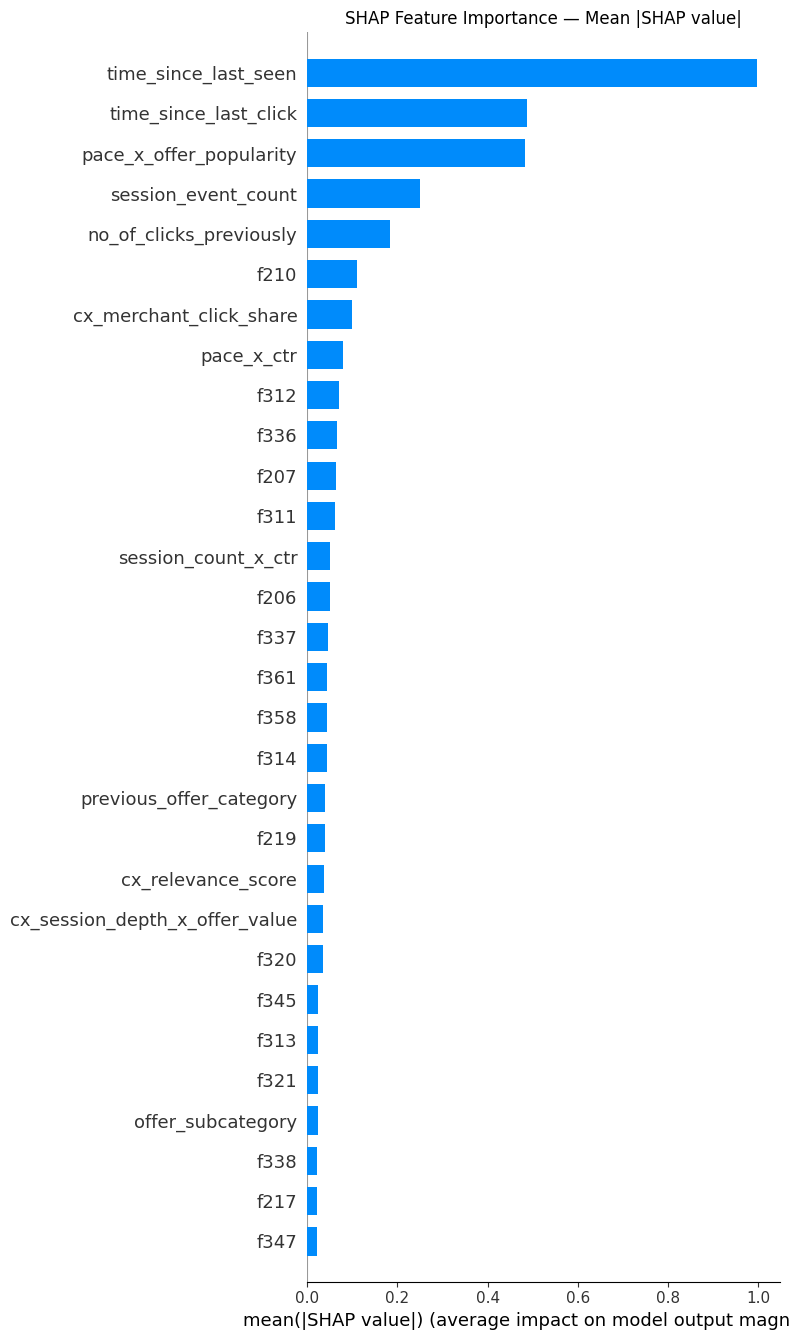

In [26]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=30, show=False)
plt.title('SHAP Feature Importance — Mean |SHAP value|')
plt.tight_layout()
plt.savefig('/Users/akashjaiswal/Desktop/amex-hackathon-4/output/shap_bar_featured.png', dpi=120, bbox_inches='tight')
plt.show()

### 10C. SHAP Dependence Plots (Top 4 Features)

2×2 grid of scatter plots, one per top-4 feature. X-axis = feature value, Y-axis = SHAP value for that feature, dot color = auto-selected interacting feature.

Shows the functional form of each feature's effect on ranking score — whether it is monotone, threshold-based, or interaction-dependent.

Saved to `output/shap_dependence_featured.png`.

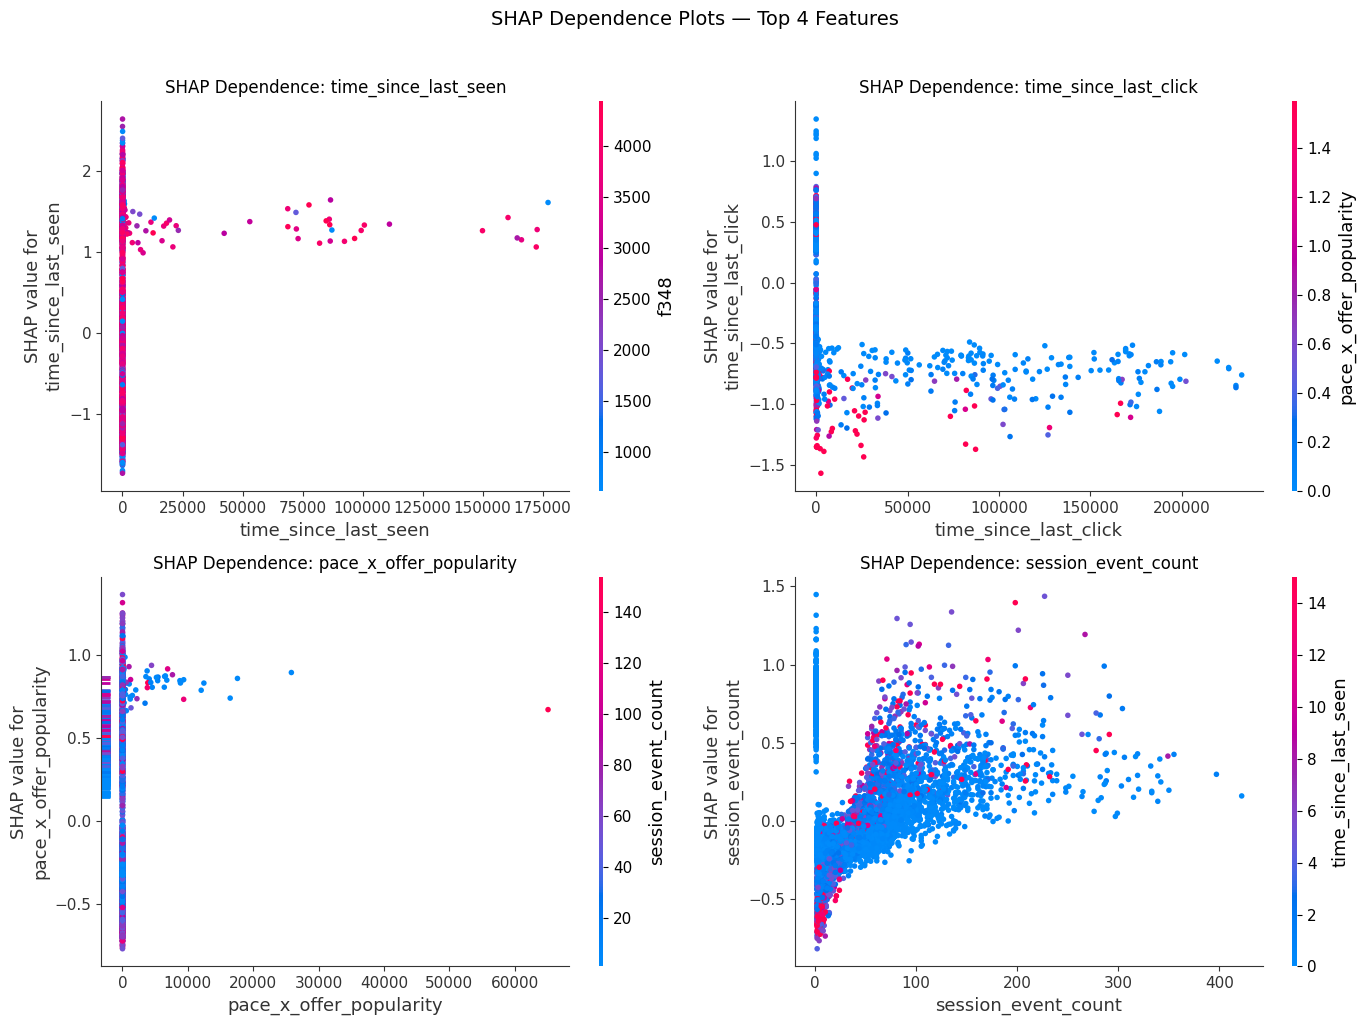

In [27]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = np.array(FEATURE_COLS)[np.argsort(mean_abs_shap)[::-1][:4]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top_features):
    shap.dependence_plot(feat, shap_values, X_shap, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')
plt.suptitle('SHAP Dependence Plots — Top 4 Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('/Users/akashjaiswal/Desktop/amex-hackathon-4/output/shap_dependence_featured.png', dpi=120, bbox_inches='tight')
plt.show()

### 10D. SHAP Waterfall (Single Prediction)

Decomposes the ranking score for a single sample (row 0 of `X_shap`) into per-feature contributions. Starting from the expected base value, each feature either increases (red) or decreases (blue) the final predicted score.

Useful for debugging individual predictions or explaining model decisions to stakeholders.

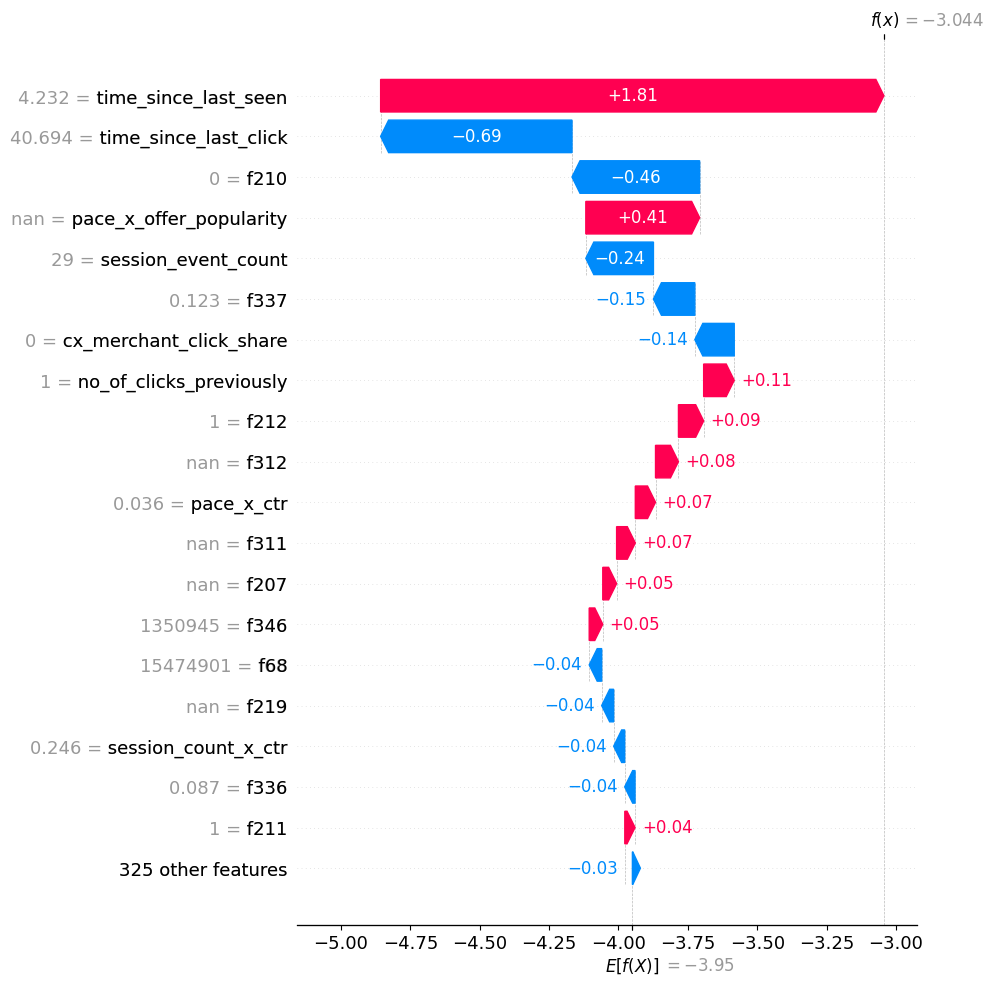

In [28]:
shap.initjs()
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_shap.iloc[0],
    feature_names=FEATURE_COLS
), max_display=20, show=True)

### 10E. SHAP on Test Set

Computes SHAP values on 3,000 randomly sampled test rows to verify that attribution patterns are stable out-of-sample. A second summary plot is generated and saved to `output/shap_summary_test_featured.png`.

If train and test SHAP distributions look similar, the model has learned generalisable patterns rather than training-set artefacts.

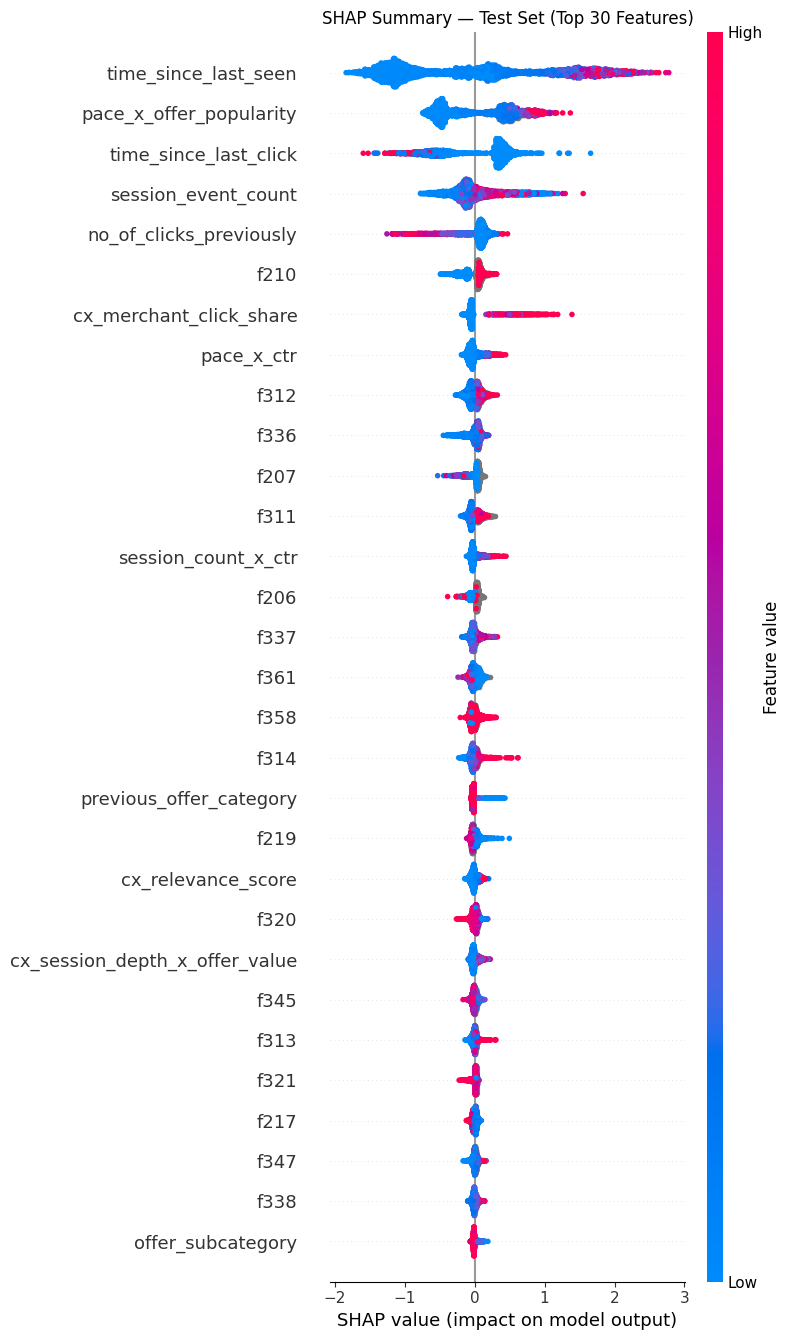

Test SHAP values computed for 3000 samples


In [30]:
TEST_SHAP_SAMPLE = min(3000, len(X_test))
X_test_shap = X_test.sample(n=TEST_SHAP_SAMPLE, random_state=42)
test_shap_values = explainer.shap_values(X_test_shap)

plt.figure(figsize=(12, 10))
shap.summary_plot(test_shap_values, X_test_shap, max_display=30, show=False)
plt.title('SHAP Summary — Test Set (Top 30 Features)')
plt.tight_layout()
plt.savefig('/Users/akashjaiswal/Desktop/amex-hackathon-4/output/shap_summary_test_featured.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Test SHAP values computed for {TEST_SHAP_SAMPLE} samples')

## Summary

| Step | Detail |
|---|---|
| Datasets | `featured_full_train.csv` / `featured_full_test.csv` (output of `feature_engineering.ipynb`) |
| Leakage cleanup | Drop `_grp_pct`, `_grp_zscore`, `_is_train` columns on load |
| Sorting | By `[id2, id4]` (customer + timestamp) |
| Cat features | None declared — all already integer-encoded; LightGBM treats them as numeric |
| Model | LightGBM `lambdarank` (truncation_level=7, label_gain=[0,1]) |
| CV | StratifiedGroupKFold (3 folds) — stratified on `y`, grouped by `id2` |
| Ensemble | Test predictions = simple average of 3 fold models |
| OOF MAP@7 | **0.6660** |
| Test MAP@7 | **0.6607** |
| Top feature | `time_since_last_seen` (gain 61,246) — recency dominates |
| SHAP | TreeExplainer on best fold (Fold 1) — beeswarm, bar, dependence (top 4), waterfall, test set |